In [1]:
from env import (
    MultiLeafThreadEnv,
    ThreadingConfig,
)
import torch
import random
from viz import draw_local_tree_sequence, draw_tree_edge_index
from utils import _timed_tree_to_graph_full
import matplotlib.pyplot as plt

from utils import build_backbone_segments_from_reference
from viz import draw_local_tree_sequence
from utils import get_max_actions

/private/home/pkatte/anaconda3/lib/python3.12/site-packages/numba/__init__.py:48: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  import scipy


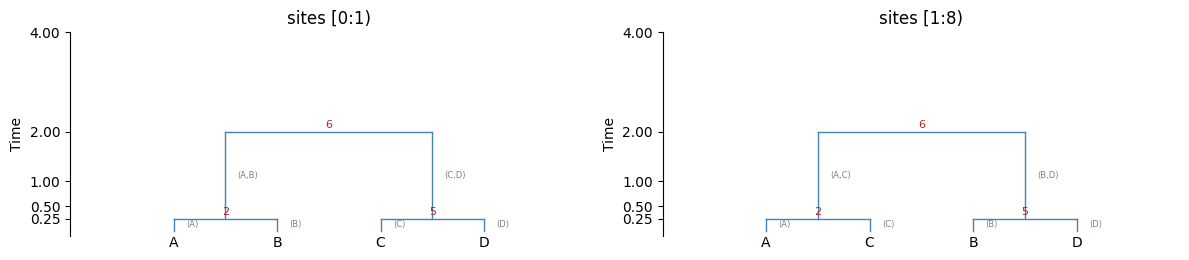

In [14]:
## First example
REFERENCE_FULL_TREES = [
    {
        "sites": (0, 1),
        # "tree": ("n", 2.0, ("n", 1.0, ("n", 1.0, 0, 1), 2), 3),
        "tree": ("n", 2.0, ("n", 0.25, 0, 1), ("n", 0.25, 2, 3)),
    },
    {
        "sites": (1, 8),
        "tree": ("n", 2.0, ("n", 0.25, 0, 2), ("n", 0.25, 1, 3)),
    },
]

GENO = torch.tensor(
    [
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1],
    ],
    dtype=torch.long,
)
LEAF_NAMES = ["A", "B", "C", "D"]
ALL_LEAF_IDS = [0, 1, 2, 3]
TIME_GRID = (0.25, 0.5, 1.0, 2.0, 4.0)

## View this tree. 

full_tree_backbone = build_backbone_segments_from_reference(REFERENCE_FULL_TREES, focal_leaf=-1)
draw_local_tree_sequence(full_tree_backbone, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)

In [15]:
multi_env_cfg = ThreadingConfig.from_raw(GENO, TIME_GRID, 0.4, 0.35, 0.15)
env = MultiLeafThreadEnv(multi_env_cfg, ALL_LEAF_IDS, REFERENCE_FULL_TREES)

In [4]:
st = env.reset()
data = env.encode(st)

In [5]:
from models import TreeMPNN
from torch.optim import Adam
import torch.nn as nn

window_size = 2
# Expected node feature dim: 1 (time) + 3 (type one-hot) + (window_size*2+1) (genotypes)
expected_dim = 1 + 3 + (window_size * 2 + 1)
model = TreeMPNN(node_feature_dim=expected_dim, hidden_dim=32, num_time_pts=len(TIME_GRID))
logZ = nn.Parameter(torch.tensor(0.0))
optimizer = Adam(list(model.parameters()) + [logZ], lr=1e-3)


In [6]:
def get_parsimony_score(full_trees, geno):
    mutations = 0
    for segment in full_trees:
        start, end = segment["sites"]
        tree = segment["tree"]
        for site in range(start, end):
            site_geno = geno[:, site]
            
            def fitch(node):
                nonlocal mutations
                if isinstance(node, int): # Leaf
                    allele = site_geno[node].item()
                    if allele == -1: return {0, 1}
                    return {allele}
                
                _, _, left, right = node
                left_alleles = fitch(left)
                right_alleles = fitch(right)
                
                intersect = left_alleles.intersection(right_alleles)
                if intersect:
                    return intersect
                else:
                    mutations += 1
                    return left_alleles.union(right_alleles)
            
            fitch(tree)
            
    recombinations = len(full_trees) - 1
    return recombinations, mutations

def custom_reward_fn(st, final_reward_from_env):
    # 1. Parsimony Score: Penalize the number of recombinations or mutations R = exp(-beta * (recombinations + mutations))
    recombinations, mutations = get_parsimony_score(st.current_full_trees, GENO)
    beta_mut = 0.5
    beta_recomb = 1.0
    import torch
    R = torch.exp(torch.tensor(-beta_mut * mutations - beta_recomb * recombinations)).item()
    return max(R, 1e-8)

n_episodes = 500
losses = []

logZ = torch.nn.Parameter(torch.tensor(-14.0))
optimizer = torch.optim.Adam(list(model.parameters()) + [logZ], lr=5e-3)

losses = []

for ep in range(n_episodes):
    st = env.reset()
    log_pf_sum = 0.0
    log_pb_sum = 0.0 # Assuming uniform backward probability P_B for simplicity during testing
    
    while not env.is_terminal(st):
        data = env.encode(st, window_size=window_size)
        valid_acts = env.valid_actions(st)
        
        # Predict actions
        logits = model(data.x, data.edge_index, data.focal_seq, data.valid_action_info).squeeze(-1)
        dist = torch.distributions.Categorical(logits=logits)
        
        # Sample an action
        action_idx = dist.sample()
        log_pf_sum += dist.log_prob(action_idx)
        
        # Step environment
        act = valid_acts[action_idx.item()]
        st, reward, done = env.step(st, act)
    
    # Calculate TB Loss
    final_reward = custom_reward_fn(st, reward)
    
    loss = (logZ + log_pf_sum - log_pb_sum - torch.log(torch.tensor(final_reward)))**2
    
    optimizer.zero_grad()
    loss.backward()
    
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    torch.nn.utils.clip_grad_norm_([logZ], 1.0)
    
    optimizer.step()
    
    losses.append(loss.item())
    if ep % 25 == 0:
        print(f"Episode {ep} | Loss: {loss.item():.4f} | LogZ: {logZ.item():.4f} | R: {final_reward}")


Episode 0 | Loss: 4978.8877 | LogZ: -13.9950 | R: 3.726653176272521e-06


Episode 25 | Loss: 5172.6484 | LogZ: -13.8700 | R: 8.315287232107949e-07


Episode 50 | Loss: 3774.9329 | LogZ: -13.7450 | R: 1.0130093869520351e-05


Episode 75 | Loss: 3352.8103 | LogZ: -13.6200 | R: 1.3709591257793363e-06


Episode 100 | Loss: 3834.9998 | LogZ: -13.4950 | R: 8.315287232107949e-07


...

Episode 375 | Loss: 17.0156 | LogZ: -12.1200 | R: 0.000335462624207139


Episode 400 | Loss: 15.9996 | LogZ: -11.9950 | R: 0.000335462624207139


Episode 425 | Loss: 15.0153 | LogZ: -11.8700 | R: 0.000335462624207139


Episode 450 | Loss: 14.0623 | LogZ: -11.7449 | R: 0.000335462624207139


Episode 475 | Loss: 13.1405 | LogZ: -11.6199 | R: 0.000335462624207139


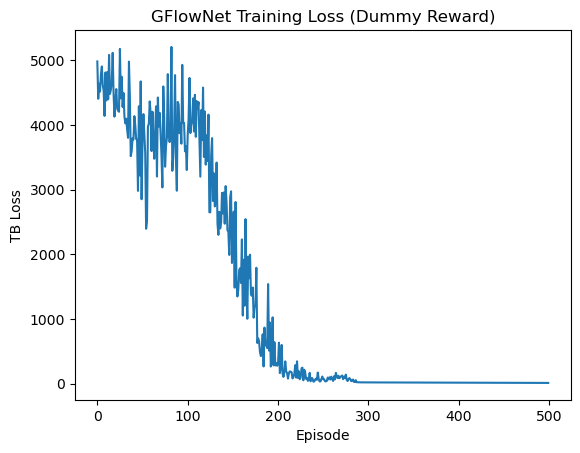

In [7]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Episode')
plt.ylabel('TB Loss')
plt.title('GFlowNet Training Loss (Dummy Reward)')
plt.show()


In [13]:
env.reference_full_trees

({'sites': (0, 2), 'tree': ('n', 2.0, ('n', 0.25, 0, 1), ('n', 0.25, 2, 3))},
 {'sites': (2, 8), 'tree': ('n', 2.0, ('n', 0.25, 0, 2), ('n', 0.25, 1, 3))})

Inferred sequence of full ARGs for every combined site boundary:
Segment 0 -> Sites (0, 1)
Segment 1 -> Sites (1, 8)


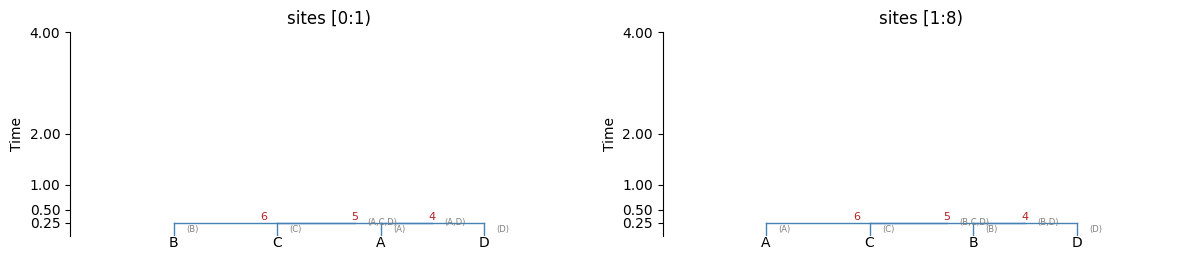

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Sample an ARG from the trained model
st = env.reset()
model.eval()

with torch.no_grad():
    while not env.is_terminal(st):
        data = env.encode(st, window_size=window_size)
        valid_acts = env.valid_actions(st)
        
        logits = model(data.x, data.edge_index, data.focal_seq, data.valid_action_info).squeeze(-1)
        dist = torch.distributions.Categorical(logits=logits)
        
        action_idx = dist.sample()
        act = valid_acts[action_idx.item()]
        st, reward, done = env.step(st, act)

# Reconstruct all the full trees from the final inferred state
final_trees = env.reconstruct_all_local_trees(st)

print("Inferred sequence of full ARGs for every combined site boundary:")
for i, segment in enumerate(final_trees):
    print(f"Segment {i} -> Sites {segment['sites']}")

# Let's draw the generated trees!
from viz import draw_local_tree_sequence
draw_local_tree_sequence(final_trees, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)
